In [139]:
%load_ext autoreload
%autoreload 2

import os
import sys
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)
import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [140]:
import pandas as pd
import numpy as np
import yfinance as yf

In [141]:
rs3000 = pd.read_csv("../data/russell3000_holdings.csv")
rs3000 = rs3000.drop(rs3000[rs3000["Sector"] == "Cash and/or Derivatives"].index)
rs3000

,Ticker,Name,Sector,Asset Class,Market Value,Weight (%),Notional Value,Quantity,Price,Location,Exchange,Currency,FX Rate,Market Currency,Accrual Date
0,AAPL,APPLE INC,Information Technology,Equity,"936,343,400.00",6.03,"936,343,400.00","3,984,440.00",235.00,United States,NASDAQ,USD,1.0,USD,-
1,NVDA,NVIDIA CORP,Information Technology,Equity,"885,161,946.00",5.70,"885,161,946.00","6,414,217.00",138.00,United States,NASDAQ,USD,1.0,USD,-
2,MSFT,MICROSOFT CORP,Information Technology,Equity,"852,374,835.04",5.49,"852,374,835.04","2,038,394.00",418.16,United States,NASDAQ,USD,1.0,USD,-
3,AMZN,AMAZON COM INC,Consumer Discretionary,Equity,"481,210,684.77",3.10,"481,210,684.77","2,546,223.00",188.99,United States,NASDAQ,USD,1.0,USD,-
4,META,META PLATFORMS INC CLASS A,Communication,Equity,"346,200,787.91",2.23,"346,200,787.91","600,553.00",576.47,United States,NASDAQ,USD,1.0,USD,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2673,CPS,COOPER STANDARD HOLDINGS INC,Consumer Discretionary,Equity,"10,047.45",0.00,"10,047.45",735.00,13.67,United States,New York Stock Exchange Inc.,USD,1.0,USD,-
2674,INH,INHIBRX INC CVR,Health Care,Equity,"8,607.20",0.00,"8,607.20","7,685.00",1.12,United States,NO MARKET (E.G. UNLISTED),USD,1.0,USD,-
2675,RAPT,RAPT THERAPEUTICS INC,Health Care,Equity,"9,995.36",0.00,"9,995.36","5,584.00",1.79,United States,NASDAQ,USD,1.0,USD,-
2676,ADRO,CHINOOK THERAPEUTICS INC CVR,Health Care,Equity,"1,938.72",0.00,"1,938.72","4,039.00",0.48,United States,NO MARKET (E.G. UNLISTED),USD,1.0,USD,-


In [142]:
price_df = yf.Tickers(rs3000["Ticker"].to_list()).history(start="2024-01-01")

[*********************100%***********************]  2674 of 2674 completed

15 Failed downloads:
['UHALB', 'BRKB', 'MOGA', 'CWENA', 'BFA', 'METCV', 'HEIA', 'BFB', 'LGFB', 'ADRO', 'LGFA', 'LENB', 'GEFB']: YFTzMissingError('$%ticker%: possibly delisted; no timezone found')
['TTC', 'INH']: YFPricesMissingError('$%ticker%: possibly delisted; no price data found  (1d 2024-01-01 -> 2024-10-20)')


In [146]:
df_ret = pd.DataFrame()
df_ret["cum_r"] = (
    np.exp(np.log(price_df["Close"].iloc[-1]) - np.log(price_df["Close"].iloc[0])) - 1
)
df_ret["q"] = pd.qcut(df_ret["cum_r"], 5, labels=False)
df_ret = pd.merge(df_ret, rs3000, on="Ticker")[["Ticker", "Sector", "cum_r", "q"]]
print(df_ret.sort_values(["q", "cum_r"], ascending=False).dropna().to_string())

     Ticker                  Sector      cum_r    q
2577    WGS             Health Care  21.746211  4.0
2143   SEZL              Financials   9.533645  4.0
2196   SMMT             Health Care   7.034090  4.0
1410   LENZ             Health Care   6.805333  4.0
223    ASTS           Communication   4.802062  4.0
2199    SMR             Industrials   4.799363  4.0
2054    RNA             Health Care   4.507642  4.0
1168   HROW             Health Care   3.810042  4.0
1299   JANX             Health Care   3.539927  4.0
1987   QTTB             Health Care   3.494196  4.0
2586   WLFC             Industrials   3.233417  4.0
659    CVNA  Consumer Discretionary   2.914672  4.0
2066   ROOT              Financials   2.834766  4.0
183     APP  Information Technology   2.744714  4.0
431    CAPR             Health Care   2.683594  4.0
2505   VKTX             Health Care   2.599562  4.0
1469   LUMN           Communication   2.566137  4.0
1935   PRAX             Health Care   2.502392  4.0
2534    VST 

In [150]:
print(
    df_ret[df_ret["Sector"] == "Information Technology"]
    .sort_values(["q", "cum_r"], ascending=False)
    .dropna()
    .to_string()
)

     Ticker                  Sector     cum_r    q
183     APP  Information Technology  2.744714  4.0
2658   ZETA  Information Technology  2.321429  4.0
1607   MSTR  Information Technology  2.150551  4.0
1721   NVDA  Information Technology  1.865587  4.0
545    CMPO  Information Technology  1.756856  4.0
2219   SOUN  Information Technology  1.644231  4.0
1908   PLTR  Information Technology  1.591677  4.0
1886     PI  Information Technology  1.538372  4.0
572    COHR  Information Technology  1.332146  4.0
2624   WULF  Information Technology  1.278261  4.0
580    COMM  Information Technology  1.115385  4.0
608    CRDO  Information Technology  1.029924  4.0
2201   SMTC  Information Technology  1.027727  4.0
530    CLMB  Information Technology  1.004843  4.0
1988   QTWO  Information Technology  0.947705  4.0
1681     NN  Information Technology  0.944444  4.0
1618   MTTR  Information Technology  0.853282  4.0
2447     UI  Information Technology  0.833528  4.0
658    CVLT  Information Techno

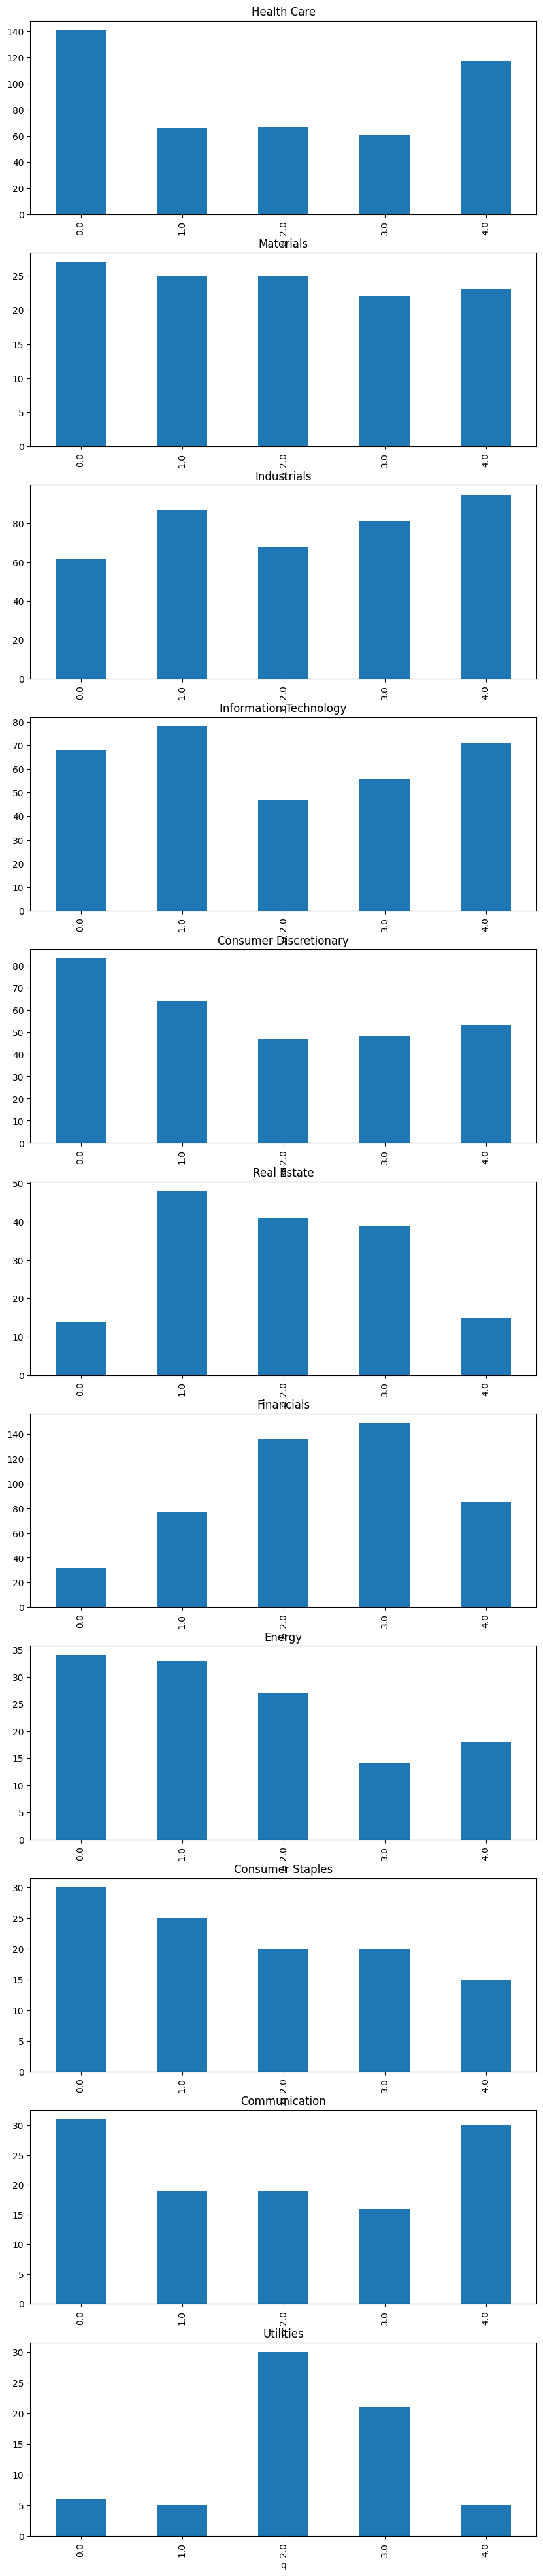

In [148]:
import matplotlib.pyplot as plt

sectors = df_ret["Sector"].drop_duplicates()
fig, axes = plt.subplots(nrows=sectors.size, ncols=1, figsize=(10, 50))

for i, sector in enumerate(sectors):
    df_ret[df_ret["Sector"] == sector]["q"].value_counts().sort_index().astype(
        "int"
    ).plot.bar(title=sector, ax=axes[i])
    # df.loc[ df["ID"] == 1, 'Value' ].plot.bar( ax=axes[0] )
    # df.loc[ df["ID"] == 2, 'Value' ].plot.bar( ax=axes[1] )

plt.show()